# Test Environment
In this playground environment you can run small localized tests on one match.

#### Imports

In [33]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [34]:
import importlib
import pandas as pd

import src.constants as constants
import src.data_processing.dataframe as dataframe
import src.data_processing.preprocessing as preprocessing
import src.features.events as events
import src.features.features as features
import src.pipeline.dataset as dataset
import src.pipeline.pipeline as pipeline
import src.model.models as models
import src.utils as utils

In [35]:
# Functions need to be reloaded after editing in .py files
importlib.reload(utils)
importlib.reload(constants)
importlib.reload(dataframe)
importlib.reload(preprocessing)
importlib.reload(events)
importlib.reload(features)
importlib.reload(dataset)
importlib.reload(pipeline)
importlib.reload(models)

<module 'src.model.models' from 'c:\\Users\\samif\\Forward Football\\pass_detection\\src\\model\\models.py'>

In [36]:
pd.set_option('display.max_columns', None)

#### Load Data

In [37]:
from src.data_processing.dataframe import excel_sheet_to_dataframe, csv_to_dataframe
from src.constants import MATCH_COORDINATES_ABSOLUTE_POSITION

tracking_df = excel_sheet_to_dataframe("../data/match_37/90042E8A-A1E5-4CA1-A078-BF3077920C48_adjusted_anonymized.xlsx", MATCH_COORDINATES_ABSOLUTE_POSITION)

pass_events_df = csv_to_dataframe("../data/match_37/90042E8A-A1E5-4CA1-A078-BF3077920C48_adjusted_passes.csv")

overall_stats = csv_to_dataframe("../data/match_37/90042E8A-A1E5-4CA1-A078-BF3077920C48_adjusted_OverallStats.csv")


#### Player Team Map

In [38]:
from src.data_processing.dataframe import build_player_team_map

player_team_map = build_player_team_map(overall_stats)

#### Make Numeric

In [39]:
from src.data_processing.preprocessing import convert_to_numeric, remove_duplicate_timestamps, sort_timestamps

print("Before: \n")
print(tracking_df.dtypes.head(10))

tracking_df = convert_to_numeric(tracking_df)

print("\nAfter: \n")
print(tracking_df.dtypes.head(10))

Before: 

timestamp     int64
ballId          str
posX            str
posY            str
playerId      int64
posX.1          str
posY.1          str
playerId.1    int64
posX.2          str
posY.2          str
dtype: object

After: 

timestamp       int64
ballId            str
posX          float64
posY          float64
playerId        int64
posX.1        float64
posY.1        float64
playerId.1      int64
posX.2        float64
posY.2        float64
dtype: object


#### Sort and Remove duplicates

In [40]:
print("Rows before:", len(pass_events_df))
pass_events_df_clean = remove_duplicate_timestamps(pass_events_df)
print("Rows after:", len(pass_events_df_clean))

print("Duplicate timestamps:", pass_events_df["timestamp"].duplicated().sum())

print("Is sorted before:", pass_events_df["timestamp"].is_monotonic_increasing)
pass_events_df_clean = sort_timestamps(pass_events_df_clean)
print("Is sorted after:", pass_events_df["timestamp"].is_monotonic_increasing)

Rows before: 610
Rows after: 610
Duplicate timestamps: 0
Is sorted before: True
Is sorted after: True


In [41]:
print("Rows before:", len(tracking_df))
tracking_df_clean = remove_duplicate_timestamps(tracking_df)
print("Rows after:", len(tracking_df_clean))

print("Duplicate timestamps:", tracking_df["timestamp"].duplicated().sum())

print("Is sorted before:", tracking_df["timestamp"].is_monotonic_increasing)
tracking_df_clean = sort_timestamps(tracking_df_clean)
print("Is sorted after:", tracking_df["timestamp"].is_monotonic_increasing)

Rows before: 19856
Rows after: 19856
Duplicate timestamps: 0
Is sorted before: True
Is sorted after: True


#### Set is_pass to 1 for all pass events

In [42]:
from src.features.events import label_passes

tracking_df_clean = label_passes(tracking_df_clean, pass_events_df_clean)

tracking_df_clean[tracking_df_clean["is_pass"] == 1].head()

,timestamp,ballId,posX,posY,playerId,posX.1,posY.1,playerId.1,posX.2,posY.2,playerId.2,posX.3,posY.3,playerId.3,posX.4,posY.4,playerId.4,posX.5,posY.5,playerId.5,posX.6,posY.6,playerId.6,posX.7,posY.7,playerId.7,posX.8,posY.8,playerId.8,posX.9,posY.9,playerId.9,posX.10,posY.10,playerId.10,posX.11,posY.11,playerId.11,posX.12,posY.12,playerId.12,posX.13,posY.13,playerId.13,posX.14,posY.14,playerId.14,posX.15,posY.15,playerId.15,posX.16,posY.16,playerId.16,posX.17,posY.17,playerId.17,posX.18,posY.18,playerId.18,posX.19,posY.19,playerId.19,posX.20,posY.20,playerId.20,posX.21,posY.21,playerId.21,posX.22,posY.22,playerId.22,posX.23,posY.23,playerId.23,posX.24,posY.24,playerId.24,posX.25,posY.25,is_pass
2,1651750573700,2942,49.0,33.0,95582,50.0,44.0,95585,61.0,21.0,95584,36.0,33.0,95597,49.0,23.0,95601,55.0,40.0,95600,30.0,30.0,95583,49.0,53.0,95598,42.0,-3.0,95987,NaN,NaN,95603,78.0,31.0,95586,42.0,24.0,95588,30.0,35.0,95580,48.0,23.0,95594,57.0,27.0,95589,32.0,46.0,95988,NaN,NaN,95986,48.0,48.0,95592,35.0,20.0,95581,39.0,34.0,95591,15.0,34.0,95593,49.0,12.0,95587,49.0,47.0,95602,49.0,33.0,95579,63.0,36.0,95595,62.0,31.0,1
15,1651750576300,2942,52.0,31.0,95582,48.0,44.0,95585,61.0,21.0,95584,35.0,35.0,95597,47.0,24.0,95601,52.0,41.0,95600,29.0,33.0,95583,43.0,52.0,95598,42.0,-3.0,95987,NaN,NaN,95603,78.0,31.0,95586,41.0,27.0,95588,29.0,38.0,95580,53.0,28.0,95594,55.0,28.0,95589,30.0,47.0,95988,NaN,NaN,95986,47.0,43.0,95592,35.0,20.0,95581,39.0,37.0,95591,15.0,34.0,95593,50.0,13.0,95587,45.0,46.0,95602,46.0,33.0,95579,60.0,38.0,95595,62.0,30.0,1
21,1651750577500,2942,36.0,39.0,95582,43.0,43.0,95585,60.0,22.0,95584,35.0,39.0,95597,42.0,25.0,95601,50.0,41.0,95600,27.0,35.0,95583,40.0,51.0,95598,42.0,-3.0,95987,NaN,NaN,95603,78.0,32.0,95586,39.0,29.0,95588,29.0,40.0,95580,53.0,31.0,95594,55.0,28.0,95589,29.0,46.0,95988,NaN,NaN,95986,44.0,42.0,95592,33.0,21.0,95581,39.0,39.0,95591,15.0,35.0,95593,48.0,14.0,95587,38.0,45.0,95602,43.0,33.0,95579,57.0,39.0,95595,60.0,31.0,1
24,1651750578100,2942,38.0,41.0,95582,41.0,41.0,95585,60.0,23.0,95584,35.0,40.0,95597,40.0,26.0,95601,48.0,41.0,95600,27.0,37.0,95583,39.0,49.0,95598,42.0,-3.0,95987,NaN,NaN,95603,77.0,32.0,95586,38.0,31.0,95588,30.0,41.0,95580,52.0,33.0,95594,54.0,30.0,95589,28.0,47.0,95988,NaN,NaN,95986,43.0,42.0,95592,32.0,22.0,95581,39.0,40.0,95591,14.0,34.0,95593,48.0,15.0,95587,35.0,43.0,95602,41.0,34.0,95579,55.0,38.0,95595,59.0,31.0,1
57,1651750584700,2942,46.0,43.0,95582,47.0,45.0,95585,55.0,28.0,95584,38.0,40.0,95597,37.0,29.0,95601,46.0,44.0,95600,31.0,37.0,95583,52.0,46.0,95598,42.0,-3.0,95987,NaN,NaN,95603,75.0,35.0,95586,40.0,36.0,95588,34.0,43.0,95580,45.0,43.0,95594,44.0,33.0,95589,37.0,48.0,95988,NaN,NaN,95986,44.0,48.0,95592,36.0,27.0,95581,45.0,44.0,95591,17.0,35.0,95593,48.0,22.0,95587,42.0,51.0,95602,36.0,41.0,95579,55.0,41.0,95595,53.0,35.0,1


#### Remove out of bounds coordinates

In [43]:
from src.data_processing.preprocessing import clean_out_of_bounds
tracking_df_before = tracking_df_clean.copy()

tracking_df_after = clean_out_of_bounds(tracking_df_clean)

In [44]:
x_cols = [c for c in tracking_df_before.columns if c.startswith("posX")]
y_cols = [c for c in tracking_df_before.columns if c.startswith("posY")]
coord_cols = x_cols + y_cols

nan_before = tracking_df_before[coord_cols].isna().sum().sum()
nan_after = tracking_df_after[coord_cols].isna().sum().sum()

print("NaN before:", nan_before)
print("NaN after:", nan_after)
print("New NaNs created:", nan_after - nan_before)

NaN before: 140818
NaN after: 140818
New NaNs created: 0


In [45]:
changed = tracking_df_before[coord_cols].ne(tracking_df_after[coord_cols])

changed_count = changed.sum().sum()

print("Total changed coordinate values:", changed_count)

Total changed coordinate values: 150296


#### Interpolate gaps Ball & Player

In [46]:
from src.data_processing.preprocessing import interpolate_all_coordinates

print("X before: ", tracking_df_clean["posX"].isna().sum())
print("Y before: ", tracking_df_clean["posY"].isna().sum())

tracking_df_interpol = interpolate_all_coordinates(tracking_df_clean, max_gap=5)

print("X after: ", tracking_df_interpol["posX"].isna().sum())
print("Y after: ", tracking_df_interpol["posY"].isna().sum())

X before:  1114
Y before:  1114
X after:  992
Y after:  992


#### Features

In [47]:
from src.features.features import (add_ball_velocity, add_ball_acceleration, 
                          add_ball_speed_prev, add_ball_direction_change, 
                          add_ball_displacement,
                          add_distance_to_nearest_player,  
                          add_distance_to_player_change,
                          add_closest_player_streak,
                          add_own_and_opposition_players_near_ball,
                          add_ball_player_proximity_flags,
                          )

tracking_df_features = add_ball_velocity(tracking_df_interpol)
tracking_df_features = add_ball_displacement(tracking_df_features)
tracking_df_features = add_ball_speed_prev(tracking_df_features)
tracking_df_features = add_ball_acceleration(tracking_df_features)


tracking_df_features = add_ball_direction_change(tracking_df_features)

tracking_df_features = add_distance_to_nearest_player(tracking_df_features, player_team_map)
tracking_df_features = add_distance_to_player_change(tracking_df_features)
tracking_df_features = add_own_and_opposition_players_near_ball(tracking_df_features, player_team_map, radius=6)
tracking_df_features = add_closest_player_streak(tracking_df_features, max_ball_speed=5)
tracking_df_features = add_ball_player_proximity_flags(tracking_df_features)

In [48]:
tracking_df_features.head(20)

,timestamp,ballId,posX,posY,playerId,posX.1,posY.1,playerId.1,posX.2,posY.2,playerId.2,posX.3,posY.3,playerId.3,posX.4,posY.4,playerId.4,posX.5,posY.5,playerId.5,posX.6,posY.6,playerId.6,posX.7,posY.7,playerId.7,posX.8,posY.8,playerId.8,posX.9,posY.9,playerId.9,posX.10,posY.10,playerId.10,posX.11,posY.11,playerId.11,posX.12,posY.12,playerId.12,posX.13,posY.13,playerId.13,posX.14,posY.14,playerId.14,posX.15,posY.15,playerId.15,posX.16,posY.16,playerId.16,posX.17,posY.17,playerId.17,posX.18,posY.18,playerId.18,posX.19,posY.19,playerId.19,posX.20,posY.20,playerId.20,posX.21,posY.21,playerId.21,posX.22,posY.22,playerId.22,posX.23,posY.23,playerId.23,posX.24,posY.24,playerId.24,posX.25,posY.25,is_pass,ball_vx,ball_vy,ball_speed,ball_dx,ball_dy,ball_displacement,ball_speed_prev,ball_acc,ball_direction_change,dist_ball_nearest_player,closest_player_id,closest_player_team,dist_ball_nearest_player_change,own_players_near_ball,opposition_players_near_ball,closest_player_streak,ball_player_close
0,1651750573300,2942,49.0,33.0,95582,50.0,44.0,95585,61.0,21.0,95584,36.0,33.0,95597,49.0,23.0,95601,55.0,39.0,95600,31.0,29.0,95583,49.0,53.0,95598,42.0,0.0,95987,NaN,NaN,95603,78.0,32.0,95586,42.0,24.0,95588,30.0,35.0,95580,48.0,23.0,95594,57.0,27.0,95589,32.0,46.0,95988,NaN,NaN,95986,48.0,50.0,95592,35.0,20.0,95581,39.0,34.0,95591,15.0,34.0,95593,49.0,12.0,95587,49.0,47.0,95602,49.0,34.0,95579,63.0,36.0,95595,61.0,31.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,95602.0,De Graafschap MB U13,NaN,1.0,0.0,0.0,1
1,1651750573500,2942,49.0,33.0,95582,50.0,44.0,95585,61.0,21.0,95584,36.0,33.0,95597,49.0,24.0,95601,55.0,40.0,95600,30.0,30.0,95583,49.0,53.0,95598,42.0,0.0,95987,NaN,NaN,95603,78.0,31.0,95586,42.0,24.0,95588,30.0,35.0,95580,48.0,23.0,95594,57.0,27.0,95589,32.0,46.0,95988,NaN,NaN,95986,48.0,49.0,95592,35.0,20.0,95581,39.0,34.0,95591,15.0,34.0,95593,49.0,12.0,95587,49.0,47.0,95602,49.0,34.0,95579,63.0,36.0,95595,61.0,31.0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,1.000000,95602.0,De Graafschap MB U13,0.000000,1.0,0.0,1.0,1
2,1651750573700,2942,49.0,33.0,95582,50.0,44.0,95585,61.0,21.0,95584,36.0,33.0,95597,49.0,23.0,95601,55.0,40.0,95600,30.0,30.0,95583,49.0,53.0,95598,42.0,0.0,95987,NaN,NaN,95603,78.0,31.0,95586,42.0,24.0,95588,30.0,35.0,95580,48.0,23.0,95594,57.0,27.0,95589,32.0,46.0,95988,NaN,NaN,95986,48.0,48.0,95592,35.0,20.0,95581,39.0,34.0,95591,15.0,34.0,95593,49.0,12.0,95587,49.0,47.0,95602,49.0,33.0,95579,63.0,36.0,95595,62.0,31.0,1,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,0.000000,1.000000e+00,0.000000,95602.0,De Graafschap MB U13,-1.000000,1.0,0.0,2.0,1
3,1651750573900,2942,49.0,33.0,95582,50.0,44.0,95585,61.0,21.0,95584,36.0,33.0,95597,49.0,23.0,95601,55.0,40.0,95600,30.0,30.0,95583,48.0,53.0,95598,42.0,0.0,95987,NaN,NaN,95603,78.0,31.0,95586,42.0,24.0,95588,30.0,35.0,95580,49.0,24.0,95594,57.0,27.0,95589,32.0,46.0,95988,NaN,NaN,95986,48.0,48.0,95592,35.0,20.0,95581,39.0,34.0,95591,15.0,34.0,95593,49.0,12.0,95587,49.0,47.0,95602,49.0,33.0,95579,63.0,37.0,95595,62.0,31.0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,0.000000,1.000000e+00,0.000000,95602.0,De Graafschap MB U13,0.000000,1.0,0.0,3.0,1
4,1651750574100,2942,49.0,33.0,95582,50.0,44.0,95585,61.0,21.0,95584,36.0,33.0,95597,49.0,23.0,95601,55.0,40.0,95600,30.0,30.0,95583,48.0,53.0,95598,42.0,0.0,95987,NaN,NaN,95603,78.0,31.0,95586,42.0,24.0,95588,29.0,36.0,95580,49.0,24.0,95594,57.0,27.0,95589,32.0,46.0,95988,NaN,NaN,95986,48.0,47.0,95592,35.0,21.0,95581,39.0,35.0,95591,15.0,34.0,95593,50.0,12.0,95587,49.0,47.0,95602,49.0,33.0,95579,63.0,37.0,95595,62.0,31.0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.000000,1.000000e+00,0.000000,95602.0,De Graafschap MB U13,0.000000,1.0,0.0,4.0,1
5,1651750574300,2942,49.0,33.0,95582,50.0,44.0,95585,61.0,21.0,95584,36.0,33.0,95597,49.0,23.0,95601,55.0,40.0,95600,30.0,30.0,95583,47.0,53.0,95598,42.0,0.0,95987,NaN,NaN,95603,78.0,31.0,95586,42.0,24.0,95588,29.0,36.0,95580,49.0,24.0,95594,57.0,27.0,95589,31.0,46.0,95988,NaN,NaN,95986,48.0,

#### Build instances with feature set (X) and corresponding labels (y)

In [49]:
from src.pipeline.dataset import build_window_meta_dataset

X, y, meta = build_window_meta_dataset(tracking_df_features, constants.WINDOW_SIZE, constants.STRIDE_LENGTH, label_mode="any")


In [50]:
# Combine X and y
df = X.copy()
df["target"] = y
df.head(20)

,x_center,y_center,ball_displacement_start_end,ball_displacement_from_pitch_origin,displacement_std,displacement_var,speed_max,speed_mean,speed_std,ball_speed_center,ball_speed_start,ball_speed_end,speed_end_minus_start,acc_max,acc_min,acc_abs_max,acc_abs_mean,speed_prev_mean,speed_prev_std,direction_max,direction_min,direction_mean,direction_std,dist_max,dist_min,dist_mean,dist_center,dist_start,dist_end,dist_end_minus_start,dist_close_start,dist_close_end,same_closest_player_all_window,closest_player_changes,closest_player_start_end_valid,closest_player_start_end_changed,closest_team_share_max,closest_team_changes,closest_team_start_end_valid,closest_team_start_end_changed,ball_player_close_share,ball_player_close_any,streak_max,streak_min,streak_mean,streak_std,streak_center,streak_start,streak_end,streak_end_minus_start,own_players_near_max,own_players_near_min,own_players_near_mean,oppo_players_near_max,oppo_players_near_min,oppo_players_near_mean,dist_player_change_mean,dist_player_change_max,dist_player_change_min,dist_player_change_std,ball_path_length,ball_straight_distance,ball_curve_distance,ball_movement_directness,ball_curve_ratio,speed_distance_interaction,speed_max_per_path_length,own_opposition_ratio_near_center,nearest_dist_opening,nearest_dist_closing,nearest_dist_pass_arc,player_changed_x_speed_max,player_changed_x_path_length,player_changed_and_close_edges,player_changed_and_high_speed,team_changed_x_speed_max,team_changed_x_path_length,high_speed_far_from_player_share,high_speed_close_to_player_share,target
0,49.0,33.0,8.062258,59.076222,0.812940,0.660872,11.180340,3.382906,4.064701,0.000000,NaN,5.000000,NaN,30.901699,-30.901699,30.901699,6.677185,2.941880,4.525470,1.000000,8.000000e-09,0.742951,0.422397,5.000000,0.0,1.475704,1.000000,1.000000,1.000000,0.000000,1,1,0,1,1,1,1.000000,0,1,0,0.666667,1,7.0,0.0,1.866667,2.503331,7.0,0.0,0.0,0.0,2.0,1.0,1.066667,1.0,0.0,0.200000,0.000000e+00,2.171573,-1.414214,1.056526,9.472136,8.062258,1.409878,0.851155,0.148845,4.992168,1.180340,5.333307,4.000000,4.000000,4.000000,11.180340,9.472136,1,1,0.000000,0.000000,0.133333,0.133333,1
1,37.0,40.0,20.615528,54.488531,1.604758,2.575248,31.622777,11.026221,8.023789,7.071068,22.360680,7.071068,-15.289612,102.212184,-87.403205,102.212184,37.220252,10.476127,8.253836,1.894427,4.000000e-09,0.492851,0.568331,4.123106,1.0,2.154261,2.236068,3.162278,2.828427,-0.333851,0,0,0,6,1,1,0.733333,4,1,0,0.333333,1,1.0,0.0,0.066667,0.258199,0.0,0.0,0.0,0.0,3.0,1.0,1.933333,3.0,0.0,1.600000,1.218951e-01,2.162278,-1.887038,1.153986,28.606528,20.615528,7.991000,0.720658,0.279342,23.753359,1.105439,1.208333,0.960828,1.294679,1.127753,31.622777,28.606528,0,1,0.000000,0.000000,0.200000,0.400000,1
2,40.0,44.0,10.770330,59.464275,1.043365,1.088610,15.811388,6.923326,5.216823,11.180340,7.071068,0.000000,-7.071068,79.056942,-55.901699,79.056942,28.420796,7.530610,4.995345,2.000000,8.000000e-09,0.630656,0.605556,3.162278,0.0,1.388892,0.000000,2.828427,0.000000,-2.828427,0,1,0,6,1,1,0.666667,4,1,0,0.600000,1,1.0,0.0,0.200000,0.414039,0.0,0.0,1.0,1.0,4.0,1.0,2.466667,5.0,1.0,2.600000,-1.885618e-01,2.828427,-1.528961,1.143402,19.355763,10.770330,8.585433,0.556440,0.443560,9.615749,0.816883,0.948718,0.333851,3.162278,1.748064,15.811388,19.355763,0,1,0.000000,0.000000,0.066667,0.466667,0
3,44.0,42.0,6.082763,60.827625,0.697581,0.486619,11.180340,4.688165,3.487904,0.000000,5.000000,10.000000,5.000000,35.355339,-25.000000,35.355339,16.881650,3.885618,2.970445,1.707107,4.000000e-08,0.861217,0.521748,3.605551,0.0,1.138951,1.000000,1.414214,3.605551,2.191338,1,0,0,8,1,0,0.800000,6,1,0,0.866667,1,1.0,0.0,0.133333,0.351866,0.0,0.0,0.0,0.0,3.0,2.0,2.133333,3.0,2.0,2.133333,2.403701e-01,1.414214,-1.000000,0.709698,13.064495,6.082763,6.981733,0.465595,0.534405,5.339589,0.855780,1.000000,2.191338,0.000000,1.095669,0.000000,0.000000,0,0,0.000000,0.000000,0.066667,0.600000,1
4,57.0,38.0,10.049876,68.505474,0.909596,0.827365,18.027756,6.635371,4.547980,5.000000,11.18034

#### Scatter Plot Matrix/Visualize Data

In [51]:
top_5_features_for_plot = [
    "player_changed_x_path_length",
    "ball_player_close_share",
    "dist_end_minus_start",
    "dist_min",
    "direction_mean",
]
import pandas as pd

df_X = pd.DataFrame(X, columns=top_5_features_for_plot)
df_X["is_pass"] = y

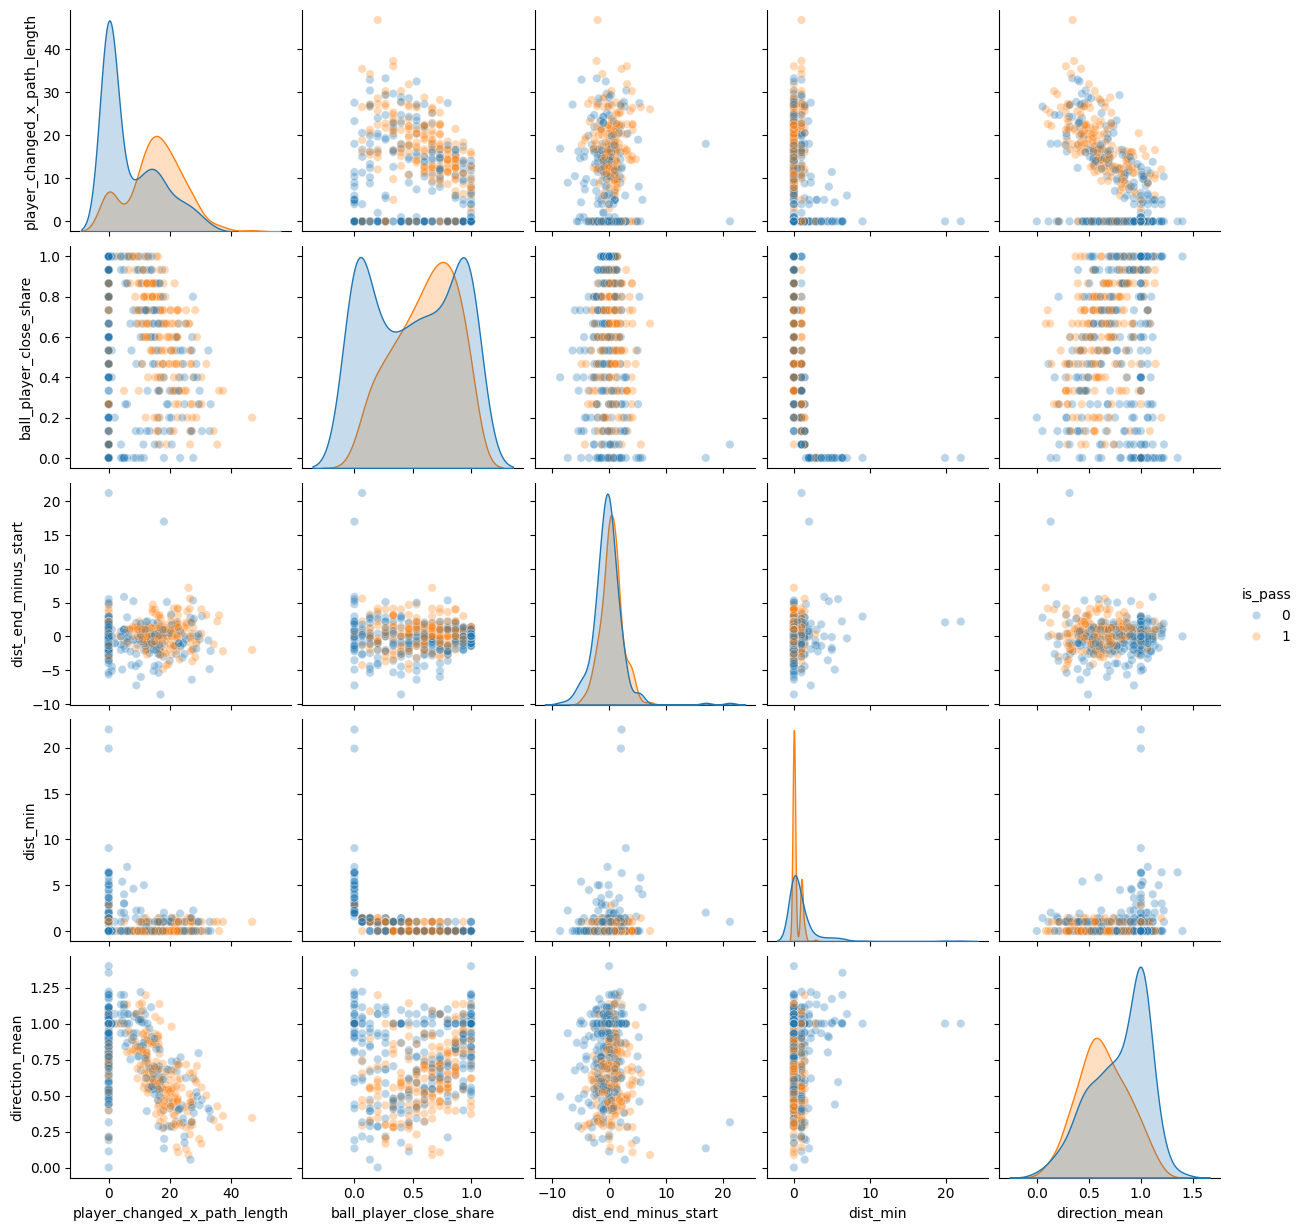

In [52]:
import seaborn as sns

# sample to avoid overload
df_sample = df_X.sample(n=500, random_state=42)

sns.pairplot(
    df_sample,
    hue="is_pass",
    diag_kind="kde",
    plot_kws={"alpha": 0.3}
)

#### Split Data 

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of pass windows:", y.sum())
print("Number of no-pass windows:", len(y) - y.sum())

X shape: (1323, 79)
y shape: (1323,)
Number of pass windows: 519
Number of no-pass windows: 804


#### Mask

In [55]:
import numpy as np
# Before mask
total_pass_before = np.sum(y_train == 1)
total_nonpass_before = np.sum(y_train == 0)

print("BEFORE MASK")
print("Pass:", total_pass_before)
print("No-pass:", total_nonpass_before)

BEFORE MASK
Pass: 412
No-pass: 646


In [56]:
X_train, y_train = dataset.apply_nan_mask(X_train, y_train)
X_val, y_val = dataset.apply_nan_mask(X_val, y_val)

In [57]:
total_pass_after = np.sum(y_train == 1)
total_nonpass_after = np.sum(y_train == 0)
print("AFTER MASK")
print("Pass:", total_pass_after)
print("No-pass:", total_nonpass_after)

AFTER MASK
Pass: 412
No-pass: 615


In [58]:
print("REMOVED")
print("Pass removed:", total_pass_before - total_pass_after)
print("No-pass removed:", total_nonpass_before - total_nonpass_after)

REMOVED
Pass removed: 0
No-pass removed: 31


In [59]:
pass_removed_pct = (total_pass_before - total_pass_after) / total_pass_before
nonpass_removed_pct = (total_nonpass_before - total_nonpass_after) / total_nonpass_before

print(f"Pass removed: {pass_removed_pct:.2%}")
print(f"No-pass removed: {nonpass_removed_pct:.2%}")

Pass removed: 0.00%
No-pass removed: 4.80%


#### Class Imbalance ratio

In [60]:
# Similar value compared to the ratio using all matches 
scale = total_nonpass_after / total_pass_after
print("scale_pos_weight:", scale)

scale_pos_weight: 1.4927184466019416


#### Model Training

Although slightly optimistic, these results show a fairly similar representation of the full dataset.


Running Logistic Regression with regular KFold CV

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params for Logistic Regression: {'model__class_weight': {0: 1, 1: 2}, 'model__C': 0.1, 'imputer': SimpleImputer()}

Best CV score: 0.7226

Best threshold: 0.500
Best F1: 0.7581
Logistic Regression - Validation results:
              precision    recall  f1-score   support

           0       0.89      0.69      0.78       154
           1       0.67      0.88      0.76       107

    accuracy                           0.77       261
   macro avg       0.78      0.79      0.77       261
weighted avg       0.80      0.77      0.77       261



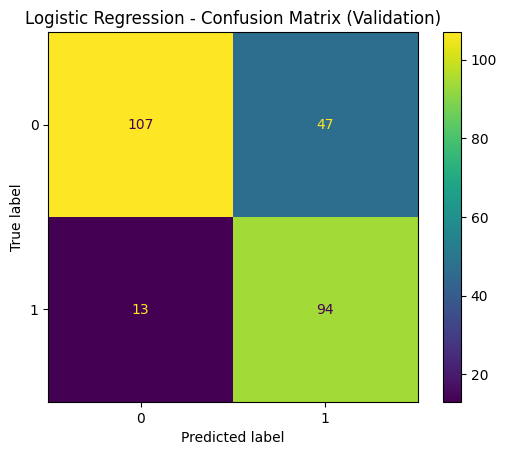

In [61]:
from src.model.models import build_model, run_random_search, find_best_threshold, evaluate_with_threshold

# Choose a model to try out
LR = "Logistic Regression"
SVM = "SVM"
DT = "Decision Tree"
RF = "Random Forest"
XGB = "XGBoost"
MLP = "MLP"

pipe, params = build_model(LR, scale)
model = run_random_search(pipe, params, LR, X, y, groups=None)
best_model = model.best_estimator_
threshold = find_best_threshold(best_model, X_val, y_val)
evaluate_with_threshold(best_model, LR, X_val, y_val, threshold)

In [62]:
features = X_train.columns

In [63]:
models.evaluate_feature_importance(best_model, X_val, y_val, features)

speed_distance_interaction             0.038314
ball_curve_distance                    0.036782
closest_team_start_end_changed         0.033844
ball_displacement_from_pitch_origin    0.033206
direction_mean                         0.028352
                                         ...   
dist_player_change_mean               -0.000128
dist_close_start                      -0.001149
direction_min                         -0.001533
dist_center                           -0.003704
closest_team_share_max                -0.004853
Length: 79, dtype: float64


speed_distance_interaction             0.038314
ball_curve_distance                    0.036782
closest_team_start_end_changed         0.033844
ball_displacement_from_pitch_origin    0.033206
direction_mean                         0.028352
                                         ...   
dist_player_change_mean               -0.000128
dist_close_start                      -0.001149
direction_min                         -0.001533
dist_center                           -0.003704
closest_team_share_max                -0.004853
Length: 79, dtype: float64